# ITQ

<img src= "img/LogoITQ.png" width="50"/>

# PAO 2025-2026

**Nombre:** *Israel Pabon* 

**Fecha:** *30/03/2026*

<img src= "img/ITQLogoING.jpeg" width="150"/>

# Variantes Cuantitativas

![logo](img/PyLogoING.jpeg)

**Israel Pabon**

In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])

In [2]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda, _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [3]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


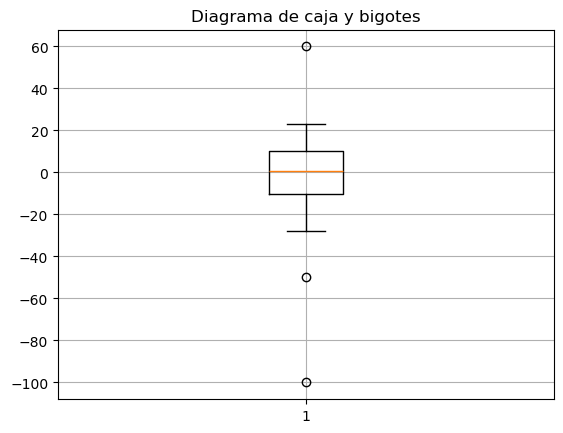

In [4]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [5]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [6]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [9]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
import pandas as pd 
iris = datasets.load_iris()

#pprint(iris)
X = iris.data
y = iris.target

# Creamos un data frame 
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Clase'] = iris.target

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
asimetria_petalo = stats.skew(df['petal length (cm)'])
print("Asimetría longitud del pétalo:", round(asimetria_petalo, 4))

# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
curtosis_sepalo = stats.kurtosis(df['sepal width (cm)'], fisher=True)
print("Curtosis ancho del sépalo:", round(curtosis_sepalo, 4))

if curtosis_sepalo > 0:
    print("Distribución Leptocúrtica")
elif curtosis_sepalo < 0:
    print("Distribución Platicúrtica")
else:
    print("Distribución Mesocúrtica")

Asimetría longitud del pétalo: -0.2721
Curtosis ancho del sépalo: 0.181
Distribución Leptocúrtica


Medias:        sepal length (cm)  sepal width (cm)  petal length (cm)  \
Clase                                                           
0                  5.006             3.428              1.462   
1                  5.936             2.770              4.260   
2                  6.588             2.974              5.552   

       petal width (cm)  
Clase                    
0                 0.246  
1                 1.326  
2                 2.026  
Desviaciones:        sepal length (cm)  sepal width (cm)  petal length (cm)  \
Clase                                                           
0               0.352490          0.379064           0.173664   
1               0.516171          0.313798           0.469911   
2               0.635880          0.322497           0.551895   

       petal width (cm)  
Clase                    
0              0.105386  
1              0.197753  
2              0.274650  


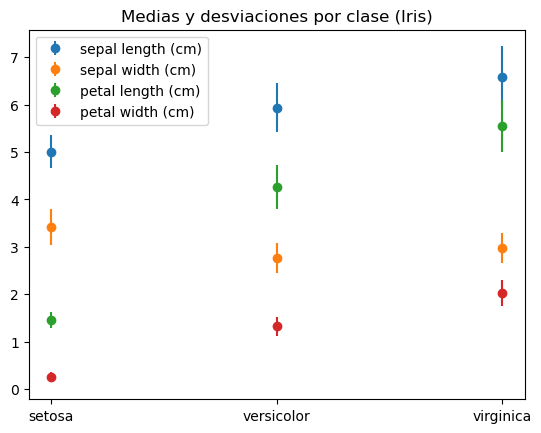

In [14]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt

# Tremos el data set de iris
iris = datasets.load_iris()

# Creamos un data frame para la organizacion del grafico
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Clase'] = iris.target

#Sacamos las medias de las clases 
medias = df.groupby('Clase').mean()
desviaciones = df.groupby('Clase').std()

print("Medias:", medias)
print("Desviaciones:", desviaciones)

# Creacion del grafico de barras de error
for col in df.columns[:-1]: 
    plt.errorbar([0,1,2], medias[col], yerr=desviaciones[col], fmt='o', label=col)

plt.xticks([0,1,2], iris.target_names)
plt.title("Medias y desviaciones por clase (Iris)")
plt.legend()
plt.show()

El resultado debería ser algo como esto:
<img src="images/errorbar.png">